[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

# Lecture 07 Filtering

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.tsa.stattools as stattools

## Trend

In [11]:
df = pd.read_csv("./NASA_GISTEMP.csv", parse_dates=["date"])
df

,Unnamed: 0,Year,Month,Anomaly,date
0,0,1990,1,0.42,1990-01-01
1,1,1990,2,0.44,1990-02-01
2,2,1990,3,0.80,1990-03-01
3,3,1990,4,0.56,1990-04-01
4,4,1990,5,0.46,1990-05-01
...,...,...,...,...,...
427,427,2025,8,1.18,2025-08-01
428,428,2025,9,1.25,2025-09-01
429,429,2025,10,1.19,2025-10-01
430,430,2025,11,1.21,2025-11-01


Text(0.5, 1.0, 'NASA GSTEMP')

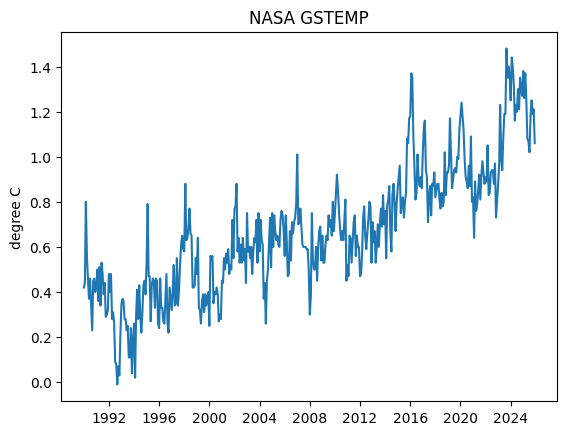

In [12]:
plt.plot(df.date, df.Anomaly)
plt.ylabel('degree C')
plt.title('NASA GSTEMP')

- trend: here we are using Numpy's polynomial fit (1st order)

(One can use statsmodels's Ordinary Linear Square Regression, which we will practice in the next lecture)

- let's get x (anomaly), length (n), and index (t)

In [13]:
anomaly = df["Anomaly"].values ### this is the Y
n = len(anomaly)
t = np.arange(n) ## df.index.values ### this is the X
print(f"t is indicies in month")

t is indicies in month



-  polynomial fit

In [14]:
slope, intercept = np.polyfit(t, anomaly, 1)

- trend & residual


In [15]:
trend = intercept+slope*t ## np.poly1d((slope, intercept))(t)

In [16]:
resid = anomaly - trend

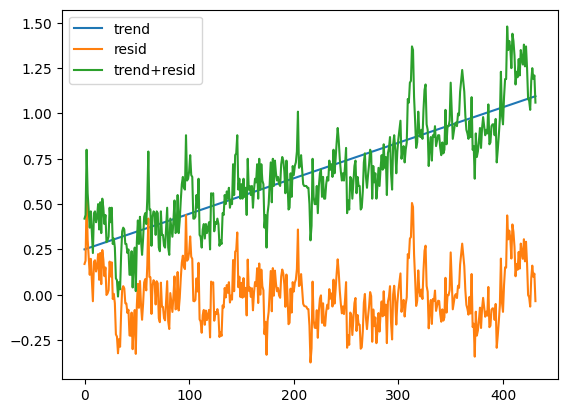

In [43]:
plt.plot(t, trend)
plt.plot(t,resid)
plt.plot(t,trend+resid)
plt.legend(['trend', 'resid', 'trend+resid'])

- report the warming rate: slope

In [18]:
slope
print('slope', slope, 'unit? per month?')

slope 0.0019608046703782495 unit? per month?


In [19]:
# Convert slope to per-year (since x_idx is in months)
slope_per_year = slope * 12

print(f"Warming trend: {slope_per_year:.4f} °C/year")


Warming trend: 0.0235 °C/year


- Confidence interval with $\alpha = 0.05$.

$CI = t_{crtical}\times SE(\hat{b})$

$SE(\hat{b}) = \frac{\hat{\sigma}_\varepsilon}{\sqrt{\sum_{t}(t-\bar{t})^2}}$

$= \frac{\sqrt{\sum_{t}\hat{\varepsilon}_t^{\,2}/(n-2)}}{\sqrt{\sum_{t}(t-\bar{t})^2}}$

In [20]:
sigma_hat = np.sqrt(np.sum(resid**2)/(n-2))
sigma_hat

np.float64(0.15353358495013247)

In [21]:
sqrt_ss_t = np.sqrt(np.sum((t - t.mean())**2))

In [22]:
SE_b_hat =sigma_hat/sqrt_ss_t
SE_b_hat

np.float64(5.9233794867469595e-05)

In [23]:
alpha = 0.05
t_critical_naive=stats.t.ppf(1-alpha/2, n-2)
print('t-stat with n:', t_critical_naive)
print(f"95% CI with n: {t_critical_naive*SE_b_hat*12:4f} °C/year")

t-stat with n: 1.9654961915712994
95% CI with n: 0.001397 °C/year


- check autocorrelation and derive effective N if necessary

In [24]:
rho1   = stattools.acf(resid, nlags=1, adjusted=False)[1]
n_eff = n * (1 - rho1) / (1 + rho1)
CI_acf = 1.96/np.sqrt(n)
print(f"rho: {rho1},CI_acf: {CI_acf} ")


rho: 0.669826360977716,CI_acf: 0.09430054396763887 


- cacluate effective SE

In [25]:
SE_b_hat_Neff = SE_b_hat*np.sqrt(n/n_eff)
SE_b_hat_Neff

np.float64(0.0001332091371618354)

In [26]:
t_critical_Neff=stats.t.ppf(1-alpha/2, n_eff-2)
print('t-crit with n:', t_critical_Neff)
print(f"95% CI with n: +/-{t_critical_Neff*SE_b_hat_Neff*12:4f} °C/year")

t-crit with n: 1.9888120224144088
95% CI with n: +/-0.003179 °C/year


In [27]:
ci = t_critical_Neff*SE_b_hat_Neff
print(f"warming rate range 95%CI: [{slope_per_year-ci*12:.4f} , {slope_per_year+ci*12:4f}] oC/year")

warming rate range 95%CI: [0.0204 , 0.026709] oC/year


In [28]:

trend_top = trend + ci*t.max()
trend_bottom = trend - ci*t.max()

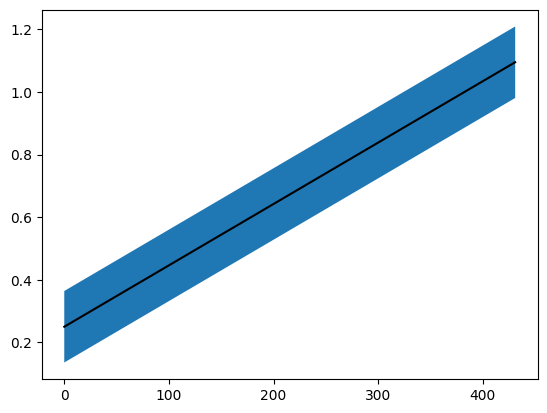

In [29]:
plt.plot(t, trend,'k')
plt.fill_between(t,trend_top, trend_bottom)


-- back to lecture --

-- hands on --

- load data, organize the data and convert Fahrenheit to Celsius

In [44]:
df = pd.read_csv("./NYC_data.csv", parse_dates=["DATE"])
df = df.dropna(subset=["TMAX"]).sort_values("DATE").reset_index(drop=True)
df["Year"] = df["DATE"].dt.year
df["Month"] = df["DATE"].dt.month
df["TMAX_C"] = (df["TMAX"] - 32) * 5/9   # Fahrenheit -> Celsius
df

,STATION,NAME,DATE,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,WT01,WT02,WT03,WT04,WT06,WT08,WT09,Year,Month,TMAX_C
0,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-01,0.00,0.0,NaN,20.0,28,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,-2.222222
1,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-02,0.00,0.0,NaN,17.0,25,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,-3.888889
2,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-03,2.42,0.0,NaN,38.0,51,24,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1999,1,10.555556
3,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-04,0.00,0.0,NaN,26.0,32,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,0.000000
4,USW00094728,"NY CITY CENTRAL PARK, NY US",1999-01-05,0.00,0.0,NaN,23.0,28,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999,1,-2.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10073,USW00094728,"NY CITY CENTRAL PARK, NY US",2026-07-31,0.03,0.0,0.0,NaN,85,67,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2026,7,29.444444
10074,USW00094728,"NY CITY CENTRAL PARK, NY US",2026-08-01,0.00,0.0,0.0,NaN,86,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026,8,30.000000
10075,USW00094728,"NY CITY CENTRAL PARK, NY US",2026-08-02,0.07,0.0,0.0,NaN,83,75,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2026,8,28.333333
10076,USW00094728,"NY CITY CENTRAL PARK, NY US",2026-08-03,1.93,0.0,0.0,NaN,80,71,1.0,NaN,1.0,NaN,NaN,NaN,NaN,2026,8,26.666667


In [60]:
## July
month = 7
sub = df[df["Month"] == month]
counts = sub.groupby("Year")["TMAX_C"].count()
yearly = sub.groupby("Year")["TMAX_C"].mean().reset_index()
yearly = yearly[yearly["Year"].isin(counts[counts >= 20].index)].reset_index(drop=True)
yearly

,Year,TMAX_C
0,1999,32.275986
1,2000,26.093190
2,2001,27.240143
3,2002,30.537634
4,2003,28.351254
5,2004,27.168459
6,2005,29.372760
7,2006,29.534050
8,2007,27.956989
9,2008,30.125448


### Seasonality

- borrow the code abvoe for calculate July mean TMAx_c each year, and loop it over to get monthly climatology

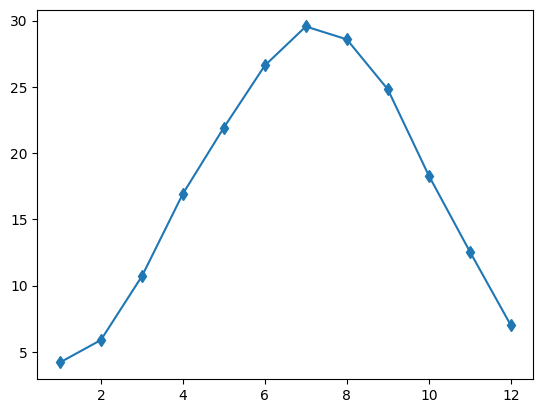

In [61]:
month_label = np.arange(1,13)
monthly = np.zeros(12)
anom_list = []
for imonth in month_label:
    sub = df[df["Month"] == imonth]
    counts = sub.groupby("Year")["TMAX_C"].count()
    yearly = sub.groupby("Year")["TMAX_C"].mean().reset_index()
    yearly = yearly[yearly["Year"].isin(counts[counts >= 20].index)].reset_index(drop=True)
    monthly[imonth-1] = yearly["TMAX_C"].mean()

plt.plot(month_label, monthly,'d-')

In [33]:
#
#    yearly["Month"] = imonth
#    yearly["anom"] = yearly["TMAX_C"] - monthly[imonth-1]
#    anom_list.append(yearly)
#anom = pd.concat(anom_list).sort_values(["Year", "Month"]).reset_index(drop=True)

- OR more advanced, useing groupby and agg function in pandas

In [62]:
g = df.groupby(["Year", "Month"])["TMAX_C"]
monthly = g.mean().reset_index()    # complete months only
clim = monthly.groupby("Month")["TMAX_C"].agg(["mean", "std", "count"])
clim

,mean,std,count
Month,,,
1,4.188428,2.451727,28
2,5.882985,2.523978,28
3,10.694444,2.189064,28
4,16.923942,1.485346,28
5,21.922043,1.436565,28
6,26.612434,1.143558,28
7,29.557732,1.573081,28
8,28.579589,1.187754,28
9,24.808642,1.264475,27


- calculate anomaly by mapping the climatology back to the time series and then subtracting form the raw data

In [63]:
monthly["anom"] = monthly["TMAX_C"] - monthly["Month"].map(clim["mean"])
monthly

,Year,Month,TMAX_C,anom
0,1999,1,4.892473,0.704045
1,1999,2,7.361111,1.478126
2,1999,3,10.358423,-0.336022
3,1999,4,16.851852,-0.072090
4,1999,5,21.702509,-0.219534
...,...,...,...,...
327,2026,4,17.981481,1.057540
328,2026,5,21.971326,0.049283
329,2026,6,27.462963,0.850529
330,2026,7,28.709677,-0.848054


<Axes: >

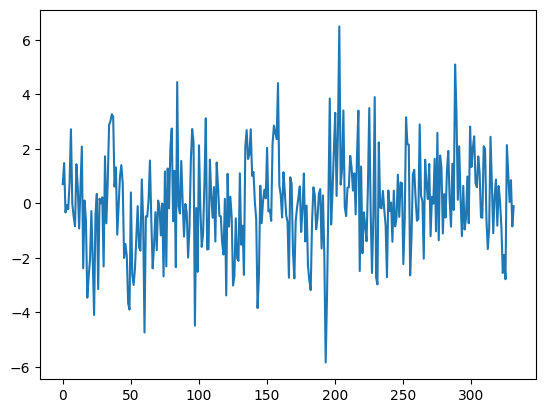

In [36]:
monthly["anom"].plot()

### running mean

1. running trend

In [37]:
monthly

,Year,Month,TMAX_C,anom
0,1999,1,4.892473,0.704045
1,1999,2,7.361111,1.478126
2,1999,3,10.358423,-0.336022
3,1999,4,16.851852,-0.072090
4,1999,5,21.702509,-0.219534
...,...,...,...,...
327,2026,4,17.981481,1.057540
328,2026,5,21.971326,0.049283
329,2026,6,27.462963,0.850529
330,2026,7,28.709677,-0.848054


$$
\bar{x}_i = \frac{1}{N}\left[\frac{1}{2}x_{i-h} + \sum_{k=-h+1}^{h-1} x_{i+k} + \frac{1}{2}x_{i+h}\right],
\qquad h = \left\lfloor \frac{N}{2} \right\rfloor,\quad h \le i \le n-h-1
$$


$$
\bar{x}_i = \frac{1}{N}\left[\sum_{k=-h}^{h} x_{i+k} \right],
\qquad h = \left\lfloor \frac{N-1}{2} \right\rfloor,\quad h \le i \le n-h-1
$$

where $N$ is `t_step`, $h$ is `t_d2`, and $n$ is the length of $x$.

OR:

$$
\bar{x}_i = \sum_{k=-h}^{h} w_k\, x_{i+k},
\qquad h = \left\lfloor \frac{K}{2} \right\rfloor,\quad h \le i \le n-h-1
$$

$$
w_k =
\begin{cases}
\dfrac{1}{K}, & |k| < h \\[6pt]
\dfrac{1}{K}, & |k| = h \text{ and } K \text{ odd} \\[6pt]
\dfrac{1}{2K}, & |k| = h \text{ and } K \text{ even}
\end{cases}
$$

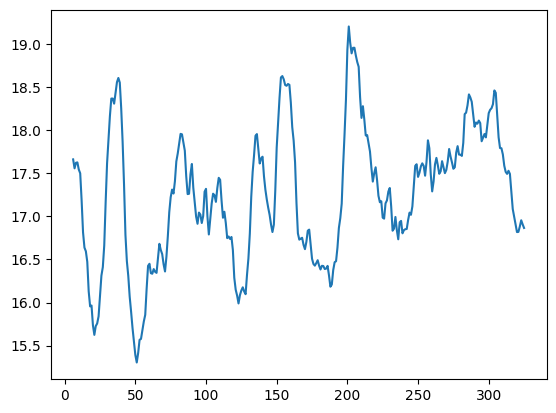

In [64]:
x = monthly["TMAX_C"].values
t_step = 12
n = len(x); out = np.full(n, np.nan)

## running mean for both even or odd number t_step
h = t_step // 2
for i in range(h, n - h):
    w = x[i-h:i+h+1].copy()
    if t_step % 2 == 0:
        w[0] *= 0.5; w[-1] *= 0.5
    out[i] = w.sum() / t_step
running_trend = pd.Series(out, index=monthly.index)
plt.plot(running_trend)
monthly['running_trend'] = running_trend


2. get de-trend monthly mean

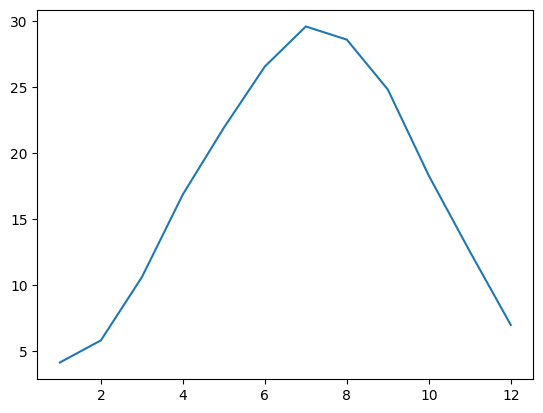

In [39]:
running_seasonal = (monthly["TMAX_C"] - running_trend).groupby(monthly["Month"]).mean()
#running_seasonal -= running_seasonal.mean()      # seasonal cycle sums to zero
plt.plot(running_seasonal+running_trend.mean())


3. get residual

In [40]:
seasonal_full = monthly["Month"].map(running_seasonal)
monthly['running_anomaly'] = monthly["TMAX_C"] - running_trend - seasonal_full


(150.0, 250.0)

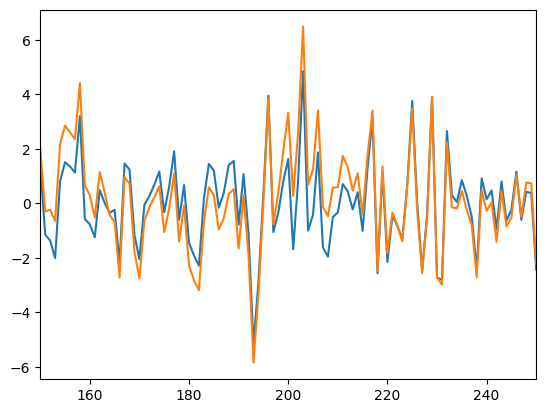

In [41]:
plt.plot(monthly['running_anomaly'])
plt.plot(monthly['anom'])
plt.xlim([150,250])

-- hands on --

In [81]:
d = pd.read_csv("PRISM_ppt_tmean_45.0000_-123.0000_189501_202607.csv")
d["Date"] = pd.to_datetime(d["Date"], format="%Y-%m")
d["Year"], d["Month"] = d.Date.dt.year, d.Date.dt.month
d["time"] = d.Year + (d.Month - 0.5) / 12
d["T"] = (d["tmean (degrees F)"] - 32) * 5 / 9                 # degC

In [66]:
d

,Date,ppt (inches),tmean (degrees F),Year,Month,time,T
0,1895-01-01,11.60,38.3,1895,1,1895.041667,3.500000
1,1895-02-01,1.77,42.5,1895,2,1895.125000,5.833333
2,1895-03-01,4.24,44.6,1895,3,1895.208333,7.000000
3,1895-04-01,2.71,51.5,1895,4,1895.291667,10.833333
4,1895-05-01,4.63,55.3,1895,5,1895.375000,12.944444
...,...,...,...,...,...,...,...
1574,2026-03-01,3.09,49.1,2026,3,2026.208333,9.500000
1575,2026-04-01,3.11,52.7,2026,4,2026.291667,11.500000
1576,2026-05-01,0.60,59.6,2026,5,2026.375000,15.333333
1577,2026-06-01,0.97,64.4,2026,6,2026.458333,18.000000


In [92]:
clim = d.groupby("Month")["T"].mean()
print(clim)
d["amon"] = d["T"]- d["Month"].map(clim)

Month
1      4.352694
2      5.989899
3      7.931818
4     10.255471
5     13.390152
6     16.415825
7     19.439815
8     19.447837
9     16.666667
10    12.054707
11     7.502969
12     4.899067
Name: T, dtype: float64


In [93]:
t= d["time"].values; y= d["amon"].values; n= len(y)
b,a = np.polyfit (t,y,n)


/usr/local/lib/python3.13/dist-packages/numpy/lib/_twodim_base_impl.py:636: RuntimeWarning: overflow encountered in accumulate
  multiply.accumulate(tmp[:, 1:], out=tmp[:, 1:], axis=1)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_polynomial_impl.py:664: RuntimeWarning: overflow encountered in multiply
  scale = NX.sqrt((lhs*lhs).sum(axis=0))
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:53: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


LinAlgError: SVD did not converge in Linear Least Squares

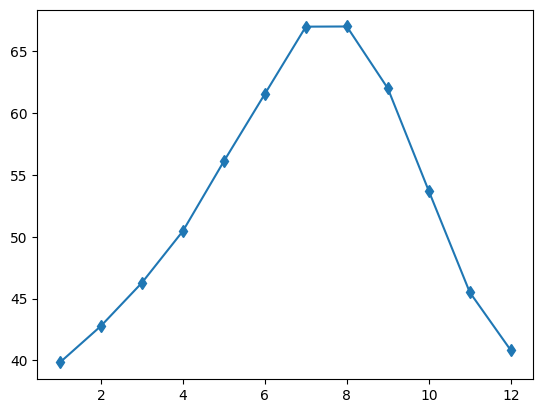

In [88]:
month_label = np.arange(1,13)
monthly = np.zeros(12)
anom_list = []
for imonth in month_label:
    sub = d[d["Month"] == imonth]
    counts = sub.groupby("Year")["tmean (degrees F)"].count()
    yearly = sub.groupby("Year")["tmean (degrees F)"].mean().reset_index()
    # yearly = yearly[yearly["Year"].isin(counts[counts >= 20].index)].reset_index(drop=True)
    monthly[imonth-1] = yearly["tmean (degrees F)"].mean()
plt.plot(month_label, monthly,'d-')

In [90]:
#monthly["anom"] = monthly["tmean (degrees F)"] - monthly["Month"].map(clim["mean"])
monthly

array([39.83484848, 42.78181818, 46.27727273, 50.45984848, 56.10227273,
       61.54848485, 66.99166667, 67.00610687, 62.        , 53.69847328,
       45.50534351, 40.81832061])